# Experiment No. 2
## Contrast Enhancement and Histogram-Based Image Processing using Python and OpenCV

* **Name:** Abhigyan Dubey
* **Course & Branch:** B.TECH CSE
* **CUID:** CU24250059
* **SUBJECT:** Computer Vision Lab
* **SEM & Section:** 5th SEM , "B"

**Aim:** To analyze and implement contrast enhancement techniques using histogram analysis and histogram equalization in Python and OpenCV for improving image quality and enhancing visual information in low-contrast images.

**Note on the image used:** This notebook lets you upload your **own image from your laptop** (Step 2). Since most personal photos aren't naturally low-contrast, the notebook also generates a synthetic **low-contrast version** of your image (by compressing its intensity range) so the enhancement techniques (contrast stretching, Histogram Equalization, CLAHE) have a meaningful effect to demonstrate and compare.

---

### Step 1: Import the required libraries

Import OpenCV, NumPy, and Matplotlib.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 5.0.0
NumPy version: 2.1.3


### Step 2: Load an image and convert it to grayscale

Upload an image from your laptop, then convert it to grayscale. We also create a synthetic **low-contrast** version of it for a clearer before/after comparison in the later steps.

Saving Natori.jpg to Natori.jpg


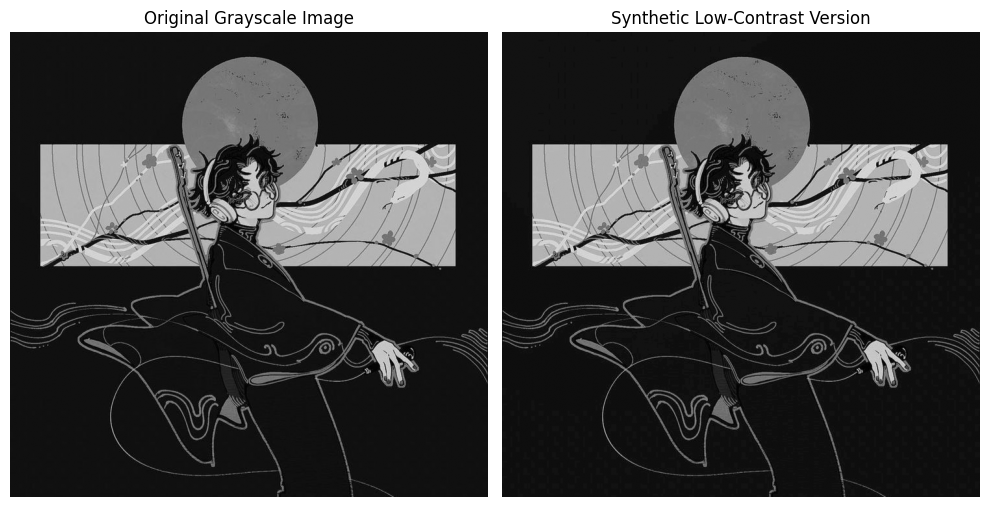

In [2]:
from google.colab import files

uploaded = files.upload()          # Choose an image file from your laptop
image_path = list(uploaded.keys())[0]

# Load the image and convert to grayscale
img_bgr = cv2.imread(image_path)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Create a synthetic low-contrast version by compressing the intensity range
# (maps the full 0-255 range down into a narrow band, e.g. 90-160)
min_out, max_out = 90, 160
low_contrast = cv2.normalize(gray, None, alpha=min_out, beta=max_out, norm_type=cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(low_contrast, cmap='gray')
plt.title("Synthetic Low-Contrast Version")
plt.axis('off')

plt.tight_layout()
plt.show()

### Step 3: Display the original image and generate its histogram

Analyze the distribution of pixel intensity values for the low-contrast image.

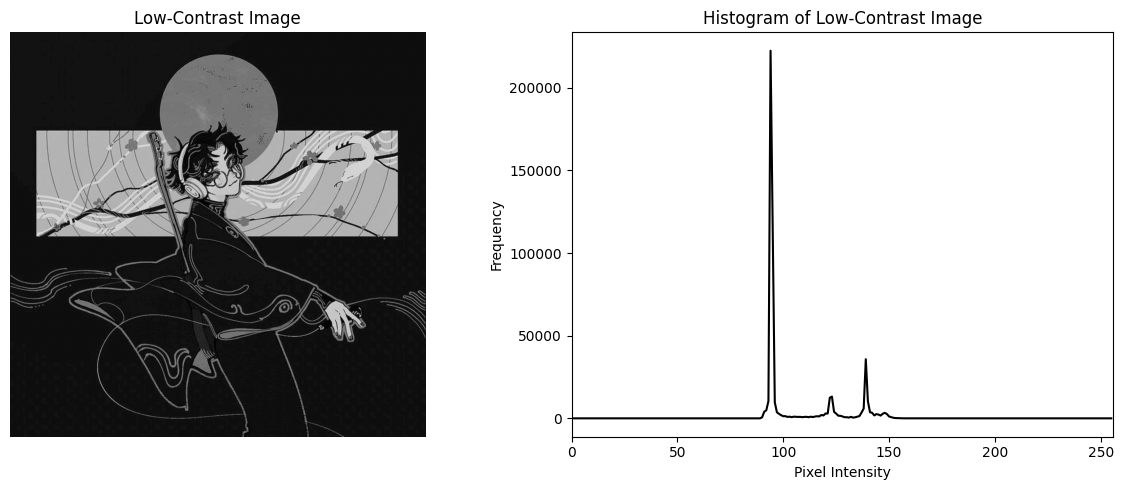

Observation: The histogram is concentrated in a narrow band of intensities,
confirming the image has low contrast (limited use of the full 0-255 range).


In [3]:
hist_low = cv2.calcHist([low_contrast], [0], None, [256], [0, 256])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(low_contrast, cmap='gray')
plt.title("Low-Contrast Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.plot(hist_low, color='black')
plt.title("Histogram of Low-Contrast Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

print("Observation: The histogram is concentrated in a narrow band of intensities,")
print("confirming the image has low contrast (limited use of the full 0-255 range).")

### Step 4: Perform contrast stretching

Improve the dynamic range of pixel intensities using min-max normalization.

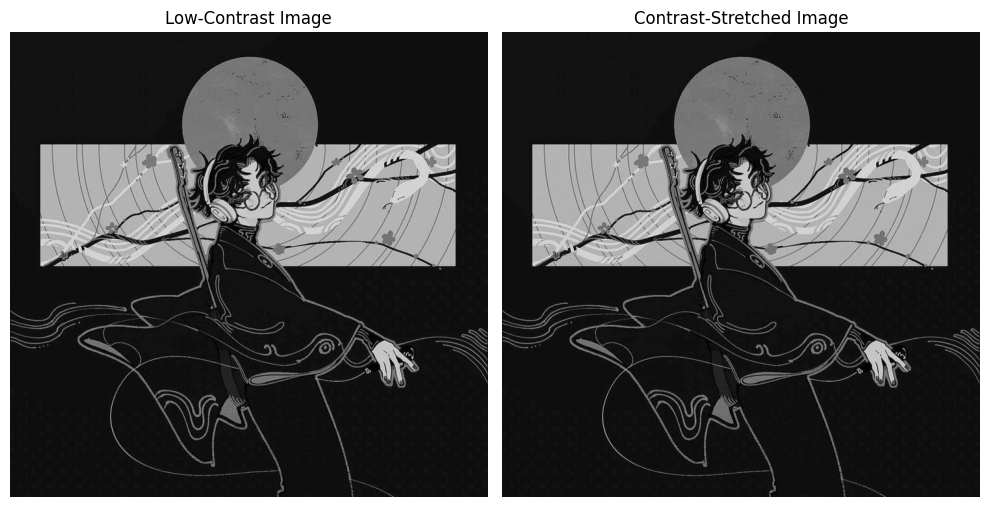

Original intensity range: [90, 160]
Stretched intensity range: [0, 255]


In [4]:
# Contrast stretching: linearly rescale intensities to the full 0-255 range
min_val, max_val = low_contrast.min(), low_contrast.max()
stretched = ((low_contrast.astype(np.float32) - min_val) / (max_val - min_val) * 255).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(low_contrast, cmap='gray')
plt.title("Low-Contrast Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(stretched, cmap='gray')
plt.title("Contrast-Stretched Image")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Original intensity range: [{min_val}, {max_val}]")
print(f"Stretched intensity range: [{stretched.min()}, {stretched.max()}]")

### Step 5: Apply Histogram Equalization

Use OpenCV's `cv2.equalizeHist()` and compare with the low-contrast original.

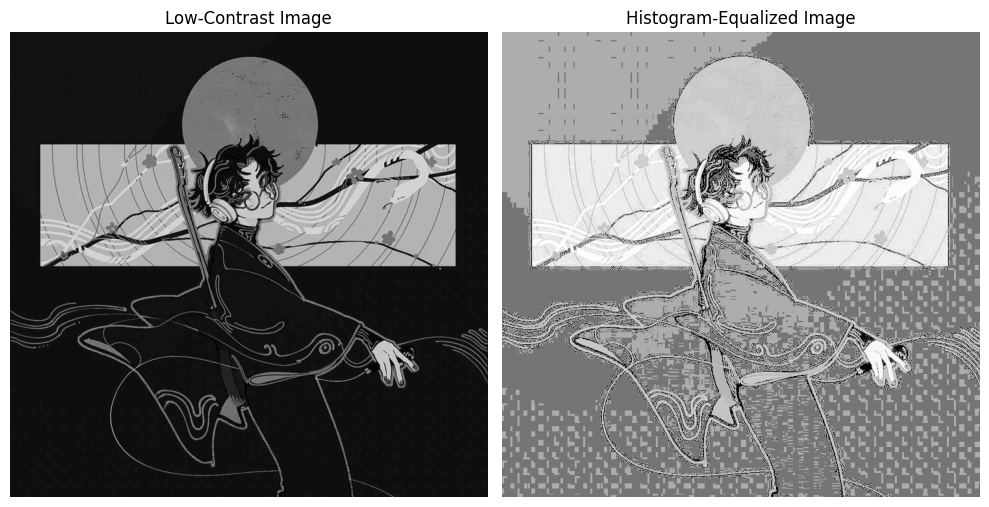

In [5]:
equalized = cv2.equalizeHist(low_contrast)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(low_contrast, cmap='gray')
plt.title("Low-Contrast Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap='gray')
plt.title("Histogram-Equalized Image")
plt.axis('off')

plt.tight_layout()
plt.show()

### Step 6: Implement CLAHE (Contrast Limited Adaptive Histogram Equalization)

Observe its performance compared to global Histogram Equalization, especially on regions with varying illumination.

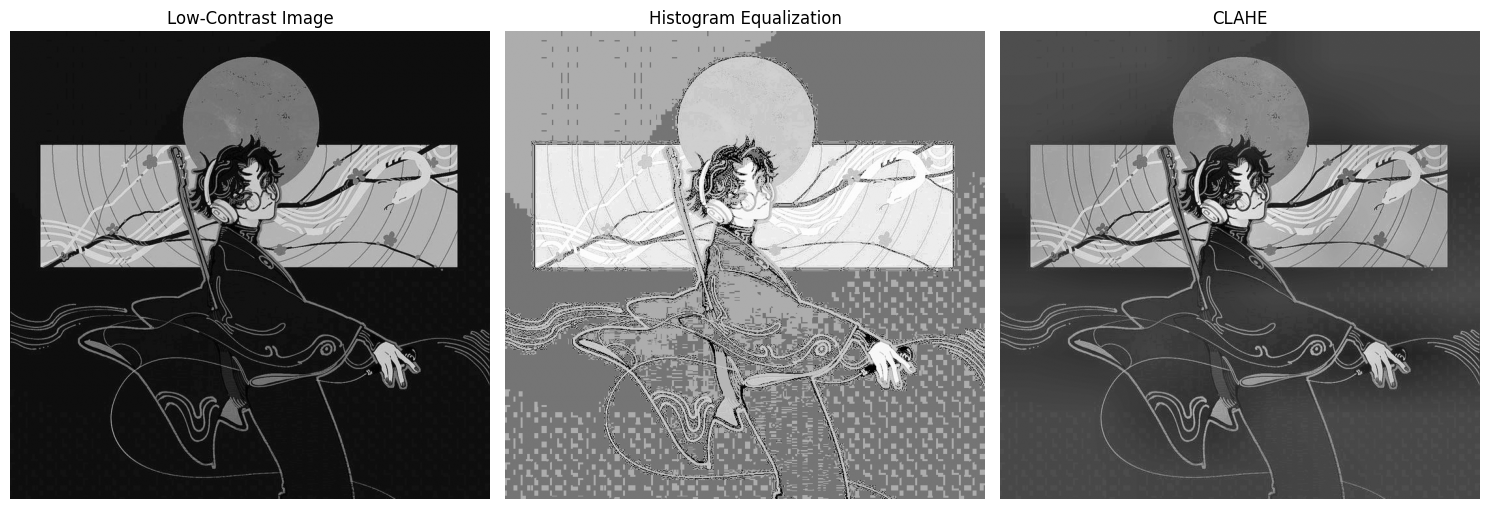

In [6]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(low_contrast)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(low_contrast, cmap='gray')
plt.title("Low-Contrast Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalization")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE")
plt.axis('off')

plt.tight_layout()
plt.show()

### Step 7: Plot and compare the histograms

Compare histograms of the original (low-contrast), histogram-equalized, and CLAHE-enhanced images.

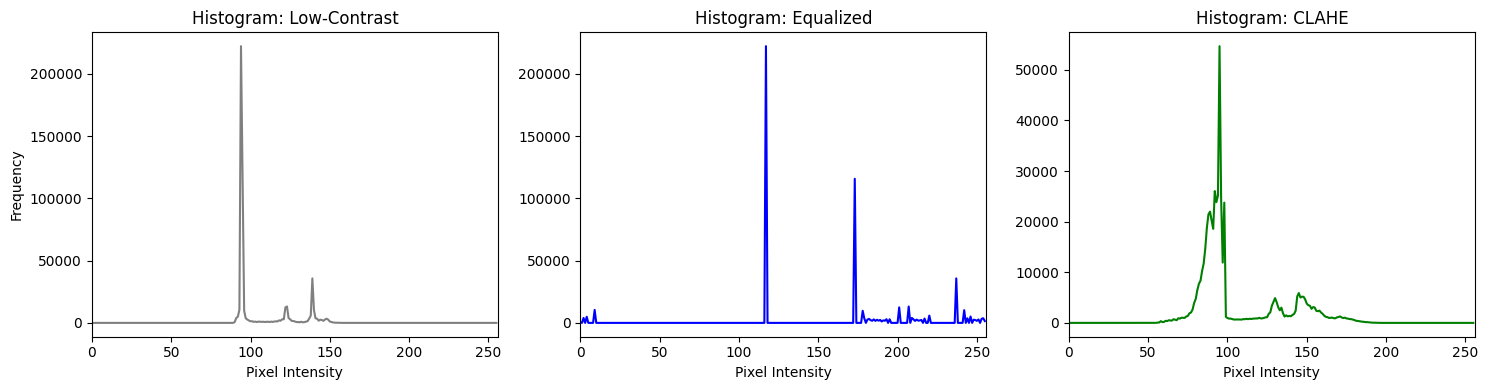

In [7]:
hist_orig = cv2.calcHist([low_contrast], [0], None, [256], [0, 256])
hist_eq = cv2.calcHist([equalized], [0], None, [256], [0, 256])
hist_clahe = cv2.calcHist([clahe_img], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(hist_orig, color='gray')
plt.title("Histogram: Low-Contrast")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.subplot(1, 3, 2)
plt.plot(hist_eq, color='blue')
plt.title("Histogram: Equalized")
plt.xlabel("Pixel Intensity")
plt.xlim([0, 256])

plt.subplot(1, 3, 3)
plt.plot(hist_clahe, color='green')
plt.title("Histogram: CLAHE")
plt.xlabel("Pixel Intensity")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

### Step 8: Analyze the visual improvements

Quantify brightness, contrast, and feature visibility using basic statistics (mean and standard deviation of pixel intensity).

In [8]:
def stats(name, image):
    print(f"{name:22s} | Mean: {image.mean():7.2f} | Std Dev (contrast): {image.std():7.2f} | Min: {image.min():3d} | Max: {image.max():3d}")

stats("Low-Contrast", low_contrast)
stats("Contrast-Stretched", stretched)
stats("Histogram-Equalized", equalized)
stats("CLAHE", clahe_img)

print("\nObservation: A higher standard deviation indicates greater spread of pixel")
print("intensities (i.e., higher contrast). Equalization and CLAHE both substantially")
print("increase the standard deviation compared to the low-contrast original.")

Low-Contrast           | Mean:  105.00 | Std Dev (contrast):   17.99 | Min:  90 | Max: 160
Contrast-Stretched     | Mean:   54.16 | Std Dev (contrast):   65.53 | Min:   0 | Max: 255
Histogram-Equalized    | Mean:  157.22 | Std Dev (contrast):   54.18 | Min:   0 | Max: 255
CLAHE                  | Mean:  105.02 | Std Dev (contrast):   26.29 | Min:  55 | Max: 196

Observation: A higher standard deviation indicates greater spread of pixel
intensities (i.e., higher contrast). Equalization and CLAHE both substantially
increase the standard deviation compared to the low-contrast original.


### Step 9: Compare the effectiveness of Histogram Equalization and CLAHE

Display both results side-by-side and discuss differences (e.g., over-enhancement of noise vs. locally balanced contrast).

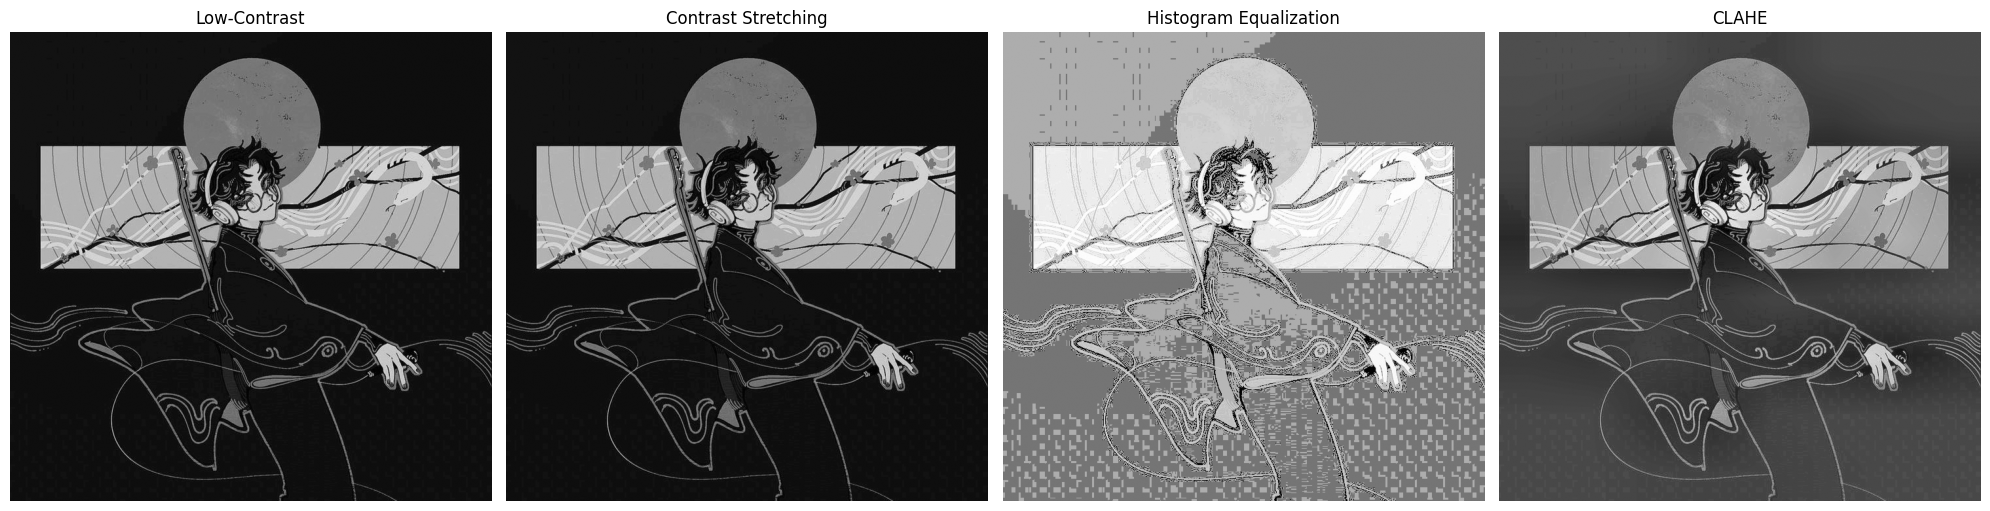

Observation: Global Histogram Equalization enhances overall contrast but can
over-amplify noise and cause loss of detail in very bright/dark regions,
since it applies a single transformation to the whole image. CLAHE applies
equalization locally (per tile) with a clip limit, giving more balanced
contrast enhancement without over-amplifying noise in any single region.


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(low_contrast, cmap='gray')
axes[0].set_title("Low-Contrast")
axes[0].axis('off')

axes[1].imshow(stretched, cmap='gray')
axes[1].set_title("Contrast Stretching")
axes[1].axis('off')

axes[2].imshow(equalized, cmap='gray')
axes[2].set_title("Histogram Equalization")
axes[2].axis('off')

axes[3].imshow(clahe_img, cmap='gray')
axes[3].set_title("CLAHE")
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("Observation: Global Histogram Equalization enhances overall contrast but can")
print("over-amplify noise and cause loss of detail in very bright/dark regions,")
print("since it applies a single transformation to the whole image. CLAHE applies")
print("equalization locally (per tile) with a clip limit, giving more balanced")
print("contrast enhancement without over-amplifying noise in any single region.")

### Step 10: Document the observations and discuss significance

- The original uploaded image was converted to grayscale, and a synthetic low-contrast version was created to clearly demonstrate the effect of each enhancement technique.
- The histogram of the low-contrast image was concentrated in a narrow intensity band, confirming poor use of the available dynamic range.
- **Contrast stretching** linearly expanded the pixel intensity range to span the full 0–255 range, improving overall visibility with a simple, computationally cheap operation.
- **Histogram Equalization** redistributed pixel intensities to flatten the histogram, significantly improving global contrast, but can over-enhance noise and wash out detail in images with strong local lighting variation.
- **CLAHE** applied equalization locally within small tiles (with a clip limit to control noise amplification), producing more natural, balanced contrast — especially useful when different regions of the image have different lighting conditions.
- Standard deviation of pixel intensities (a proxy for contrast) increased substantially after both Histogram Equalization and CLAHE compared to the low-contrast original.
- These histogram-based enhancement techniques are essential preprocessing steps in computer vision, improving the visibility of features before tasks such as edge detection, segmentation, and object recognition.

---

## Questions

**Q1. What is image contrast, and why is it important in image processing?**

**Ans:** Image contrast refers to the difference in intensity (brightness) between the light and dark regions of an image — essentially, how spread out the pixel intensity values are. It is important because higher contrast makes edges, textures, and objects more distinguishable, which directly affects the performance of downstream tasks like feature extraction, segmentation, and object recognition; low-contrast images can hide important details and make analysis difficult.

**Q2. Explain the concept of an image histogram. What information does it provide?**

**Ans:** An image histogram is a graphical representation showing the frequency (count) of each pixel intensity value (typically 0–255 for grayscale) present in an image. It provides information about the overall brightness (whether the histogram is skewed toward dark or light values), the contrast (how spread out or concentrated the distribution is), and can reveal issues like under-exposure, over-exposure, or a narrow dynamic range.

**Q3. Differentiate between Histogram Stretching and Histogram Equalization.**

**Ans:** Histogram (contrast) stretching is a linear operation that rescales the existing minimum and maximum pixel intensities to span the full available range (e.g., 0–255), preserving the relative shape of the histogram. Histogram equalization is a non-linear operation that redistributes pixel intensities based on the cumulative distribution function (CDF) of the image, spreading out the most frequent intensity values to produce a more uniform histogram, which typically results in a stronger contrast enhancement than simple stretching.

**Q4. What is Contrast Limited Adaptive Histogram Equalization (CLAHE)? How does it differ from standard Histogram Equalization?**

**Ans:** CLAHE is a variant of histogram equalization that divides the image into small regions called tiles, applies histogram equalization independently to each tile, and uses a "clip limit" to cap and redistribute excessive contrast amplification (which prevents noise over-enhancement). It differs from standard (global) Histogram Equalization, which applies a single equalization transformation to the entire image at once — CLAHE's localized, clipped approach makes it better suited for images with varying illumination across different regions, avoiding the over-enhancement issues of the global method.

**Q5. Why is histogram equalization commonly applied before feature extraction and image segmentation?**

**Ans:** Feature extraction and segmentation algorithms rely on detecting differences in intensity (edges, boundaries, textures) between regions. Histogram equalization enhances contrast so these intensity differences become more pronounced and consistent, making features and object boundaries easier for algorithms to detect accurately, especially in images that were originally poorly lit or low-contrast.

**Q6. Mention three real-world applications where histogram equalization is widely used.**

**Ans:** (1) Medical imaging, to enhance the visibility of structures in X-rays, CT scans, and MRIs. (2) Satellite and remote sensing imagery, to improve visibility of terrain and features captured under varying atmospheric or lighting conditions. (3) Surveillance and low-light photography enhancement, to make objects and faces more visible in poorly lit footage or images.

**Q7. What are the limitations of global histogram equalization?**

**Ans:** Global histogram equalization applies a single transformation across the entire image, which can over-amplify noise in relatively uniform regions, cause loss of detail (washing out) in already bright or dark areas, and fail to properly enhance images with significant local variation in lighting, since it doesn't account for regional differences in intensity distribution.

**Q8. How does contrast enhancement improve the performance of object detection and recognition systems?**

**Ans:** Contrast enhancement makes the boundaries and distinguishing features of objects (edges, textures, shapes) more visible and pronounced against their background, which helps object detection and recognition algorithms extract more reliable and discriminative features. This typically leads to improved detection accuracy, especially for images captured under poor lighting or low-contrast conditions where objects might otherwise blend into the background.

**Q9. Compare histogram-based enhancement techniques with brightness adjustment methods.**

**Ans:** Brightness adjustment methods (e.g., simply adding or subtracting a constant value from every pixel) uniformly shift all intensity values up or down, which changes overall brightness but does not change the spread (contrast) of the intensity distribution. Histogram-based techniques like equalization and CLAHE, in contrast, redistribute pixel intensities based on the image's actual intensity distribution, actively improving contrast and revealing details in both dark and bright regions rather than just uniformly shifting brightness.

**Q10. Why is CLAHE preferred for medical imaging and low-light image enhancement?**

**Ans:** Medical images and low-light photographs often have significant local variation in illumination and fine details that need to be preserved without amplifying noise. CLAHE's tile-based, localized equalization enhances contrast in each region according to its own local intensity distribution, while the clip limit prevents excessive noise amplification — making it well suited to reveal subtle structures (e.g., tissues, tumors) in medical scans or details in dark regions of low-light images without introducing the artifacts that global histogram equalization would.